# Audio ResNet Final VF

Final training-only notebook for six-class audio event classification. It keeps only the winning pretrained ResNet spectrogram branch and trains it with stronger settings for the final score, reliability, calibration, and explainability run.

## Coverage

- Raw audio dataset scanning and audit
- Deduplication before splitting
- Train-only augmentation for minority classes
- Log-mel spectrogram normalization and 224 x 224 resizing
- 70 / 15 / 15 stratified split
- Pretrained ResNet34 backbone
- Frozen phase then full fine-tuning
- Custom classification head with dropout and BatchNorm
- Differential optimization for backbone and head
- Cross-entropy loss with class weights and label smoothing
- MixUp, waveform augmentation, and spectrogram masking
- Temperature calibration and test-time augmentation
- Accuracy, macro F1, weighted F1, precision, recall, AUC, ECE, latency, parameter count, model size
- Confusion matrices, learning curves, calibration plots, per-class report, top confusions
- Grad-CAM and LIME-style XAI displayed inside the notebook
- Local CSV/JSON tracking and final model export

## Dependencies

In [1]:
import importlib.util, subprocess, sys
needed = [("librosa", "librosa"), ("soundfile", "soundfile"), ("seaborn", "seaborn"), ("tqdm", "tqdm"), ("scikit-learn", "sklearn")]
missing = [pkg for pkg, mod in needed if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Dependencies ready")

Dependencies ready


## Configuration

In [2]:
import os
from pathlib import Path
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
os.environ.setdefault("TQDM_DISABLE", "1")
CFG = {
    "output_dir": "/kaggle/working/audio_resnet_final_vf",
    "model_dir": "/kaggle/working/audio_resnet_final_vf/models",
    "xai_dir": "/kaggle/working/audio_resnet_final_vf/xai",
    "tmp_dir": "/tmp/audio_resnet_final_vf",
    "ds_esc50": "/kaggle/input/datasets/niranjankn/esc50/ESC-50-master",
    "ds_urban": "/kaggle/input/datasets/chrisfilo/urbansound8k",
    "ds_ravdess": "/kaggle/input/datasets/dejolilandry/ravdess/Radvess",
    "ds_cremad": "/kaggle/input/datasets/ejlok1/cremad/AudioWAV",
    "ds_gunshot": "/kaggle/input/datasets/emrahaydemr/gunshot-audio-dataset",
    "ds_siren": "/kaggle/input/datasets/vishnu0399/emergency-vehicle-siren-sounds/sounds",
    "ds_babycry": "/kaggle/input/datasets/warcoder/infant-cry-audio-corpus/donateacry_corpus",
    "ds_music": "/kaggle/input/datasets/lnicalo/gtzan-musicspeech-collection/music_wav",
    "sample_rate": 32000,
    "segment_duration": 3.0,
    "n_mels": 96,
    "image_size": 224,
    "max_per_class": 1800,
    "augment_targets": {"glass_break": 900, "baby_cry": 900, "gunshot": 1000},
    "batch_size": 32,
    "num_workers": 0,
    "frozen_epochs": 4,
    "full_epochs": 16,
    "head_lr": 8e-4,
    "full_head_lr": 4e-4,
    "backbone_lr": 7e-5,
    "weight_decay": 8e-4,
    "label_smoothing": 0.04,
    "mixup_alpha": 0.16,
    "early_stop_patience": 5,
    "tta_shifts": [-8, 0, 8],
    "xai_examples_per_class": 1,
    "lime_masks": 80,
    "show_progress": False,
    "quiet_external_output": True,
    "seed": 42
}
for key in ["output_dir", "model_dir", "xai_dir", "tmp_dir"]:
    Path(CFG[key]).mkdir(parents=True, exist_ok=True)
print("Config loaded")

Config loaded


## Imports and Labels

In [3]:
import gc, csv, json, math, time, random, hashlib, warnings, contextlib, sys, os
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import librosa, soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import Ridge
from IPython.display import display, Markdown, Image, FileLink
warnings.filterwarnings("ignore")
@contextlib.contextmanager
def mute_output(enabled=True):
    if not enabled:
        yield
        return
    with open(os.devnull, "w") as devnull:
        old_stdout = os.dup(1)
        old_stderr = os.dup(2)
        try:
            os.dup2(devnull.fileno(), 1)
            os.dup2(devnull.fileno(), 2)
            with contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
                yield
        finally:
            os.dup2(old_stdout, 1)
            os.dup2(old_stderr, 2)
            os.close(old_stdout)
            os.close(old_stderr)
SEED = CFG["seed"]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TARGET_CLASSES = ["gunshot", "glass_break", "alarm_signal", "human_voice", "baby_cry", "background"]
CLASS2IDX = {c: i for i, c in enumerate(TARGET_CLASSES)}
IDX2CLASS = {i: c for c, i in CLASS2IDX.items()}
NUM_CLASSES = len(TARGET_CLASSES)
print(f"Device: {DEVICE}")
print(f"Classes: {TARGET_CLASSES}")

Device: cuda
Classes: ['gunshot', 'glass_break', 'alarm_signal', 'human_voice', 'baby_cry', 'background']


## Data Collection and Preprocessing

In [4]:
ESC50_MAP = {
    "glass_breaking": "glass_break", "siren": "alarm_signal", "clock_alarm": "alarm_signal", "car_horn": "alarm_signal",
    "crying_baby": "baby_cry", "laughing": "human_voice", "coughing": "human_voice", "sneezing": "human_voice",
    "clapping": "human_voice", "breathing": "human_voice", "snoring": "human_voice",
    "dog": "background", "footsteps": "background", "drinking_sipping": "background", "brushing_teeth": "background",
    "keyboard_typing": "background", "mouse_click": "background", "door_wood_knock": "background", "door_wood_creaks": "background",
    "can_opening": "background", "pouring_water": "background", "toilet_flush": "background", "washing_machine": "background",
    "vacuum_cleaner": "background", "clock_tick": "background", "engine": "background", "helicopter": "background",
    "chainsaw": "background", "hand_saw": "background", "airplane": "background", "train": "background",
    "fireworks": "background", "church_bells": "background", "crackling_fire": "background", "thunderstorm": "background",
    "rain": "background", "sea_waves": "background", "wind": "background", "water_drops": "background",
    "insects": "background", "crickets": "background", "cat": "background", "rooster": "background",
    "hen": "background", "frog": "background", "crow": "background", "cow": "background", "pig": "background",
    "sheep": "background", "chirping_birds": "background"
}
URBAN_MAP = {
    "gun_shot": "gunshot", "siren": "alarm_signal", "car_horn": "alarm_signal", "children_playing": "human_voice",
    "dog_bark": "background", "street_music": "background", "air_conditioner": "background", "engine_idling": "background",
    "drilling": "background", "jackhammer": "background"
}
RAVDESS_MAP = {f"{i:02d}": "human_voice" for i in range(1, 9)}
CREMAD_MAP = {e: "human_voice" for e in ["NEU", "HAP", "SAD", "ANG", "DIS", "FEA"]}

def scan_esc50():
    root = Path(CFG["ds_esc50"])
    csv_path = root / "meta" / "esc50.csv"
    audio_dir = root / "audio"
    if not csv_path.exists():
        return []
    out = []
    with open(csv_path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            label = ESC50_MAP.get(row["category"])
            path = audio_dir / row["filename"]
            if label and path.exists():
                out.append((str(path), label, "esc50"))
    return out

def scan_urbansound8k():
    root = Path(CFG["ds_urban"])
    csv_path = root / "UrbanSound8K.csv"
    if not csv_path.exists():
        return []
    out = []
    with open(csv_path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            label = URBAN_MAP.get(row["class"])
            path = root / f"fold{row['fold']}" / row["slice_file_name"]
            if label and path.exists():
                out.append((str(path), label, "urban"))
    return out

def scan_ravdess():
    root = Path(CFG["ds_ravdess"])
    if not root.exists():
        return []
    out = []
    for actor in sorted(root.iterdir()):
        if actor.is_dir():
            for path in actor.glob("*.wav"):
                parts = path.stem.split("-")
                if len(parts) >= 3:
                    label = RAVDESS_MAP.get(parts[2])
                    if label:
                        out.append((str(path), label, "ravdess"))
    return out

def scan_cremad():
    root = Path(CFG["ds_cremad"])
    if not root.exists():
        return []
    out = []
    for path in root.glob("*.wav"):
        parts = path.stem.split("_")
        if len(parts) >= 3:
            label = CREMAD_MAP.get(parts[2])
            if label:
                out.append((str(path), label, "cremad"))
    return out

def scan_gunshot():
    root = Path(CFG["ds_gunshot"])
    return [(str(p), "gunshot", "gunshot") for p in root.rglob("*.wav")] if root.exists() else []

def scan_siren():
    root = Path(CFG["ds_siren"])
    if not root.exists():
        return []
    out = []
    for name in ["ambulance", "firetruck"]:
        folder = root / name
        if folder.exists():
            out.extend((str(p), "alarm_signal", "siren_ds") for p in folder.glob("*.wav"))
    traffic = root / "traffic"
    if traffic.exists():
        out.extend((str(p), "background", "siren_traffic") for p in traffic.glob("*.wav"))
    return out

def scan_babycry():
    root = Path(CFG["ds_babycry"])
    if not root.exists():
        return []
    out = []
    for folder in sorted(root.iterdir()):
        if folder.is_dir():
            out.extend((str(p), "baby_cry", "babycry") for p in folder.glob("*.wav"))
    return out

def scan_music():
    root = Path(CFG["ds_music"])
    return [(str(p), "background", "music") for p in root.glob("*.wav")] if root.exists() else []

def fingerprint_audio(path):
    try:
        y, _ = librosa.load(path, sr=8000, mono=True, duration=3.0)
        return hashlib.sha256((np.clip(y, -1, 1) * 127).astype(np.int8).tobytes()).hexdigest()[:16]
    except Exception:
        return None

def deduplicate(samples):
    seen, out = set(), []
    for item in samples:
        fp = fingerprint_audio(item[0])
        if fp is None or fp not in seen:
            if fp is not None:
                seen.add(fp)
            out.append(item)
    print(f"Dedup: {len(samples)} -> {len(out)}")
    return out

def cap_per_class(samples, cap):
    buckets = defaultdict(list)
    rng = random.Random(SEED)
    for item in samples:
        buckets[item[1]].append(item)
    out = []
    for cls in TARGET_CLASSES:
        rows = buckets.get(cls, [])
        rng.shuffle(rows)
        out.extend(rows[:cap] if cap else rows)
    rng.shuffle(out)
    return out

def prepare_splits(samples):
    labels = [s[1] for s in samples]
    strat = [f"{s[1]}_{s[2]}" for s in samples]
    counts = Counter(strat)
    safe = [st if counts[st] >= 3 else labels[i] for i, st in enumerate(strat)]
    train_val, test = train_test_split(samples, test_size=0.15, stratify=safe, random_state=SEED)
    train, val = train_test_split(train_val, test_size=0.15 / 0.85, stratify=[s[1] for s in train_val], random_state=SEED)
    return train, val, test

def augment_minority(samples, cls, target):
    src = [s for s in samples if s[1] == cls]
    if not src or len(src) >= target:
        return samples
    out_dir = Path(CFG["tmp_dir"]) / "aug"
    out_dir.mkdir(parents=True, exist_ok=True)
    aug = []
    i = 0
    while len(src) + len(aug) < target and i < target * 8:
        path, label, source = src[i % len(src)]
        try:
            y, _ = librosa.load(path, sr=CFG["sample_rate"], mono=True)
            mode = i // len(src)
            if mode % 4 == 0:
                y = librosa.effects.pitch_shift(y, sr=CFG["sample_rate"], n_steps=np.random.uniform(-2.0, 2.0))
            elif mode % 4 == 1:
                y = librosa.effects.time_stretch(y, rate=np.random.uniform(0.9, 1.1))
            elif mode % 4 == 2:
                y = y + np.random.normal(0, 0.005, len(y)).astype(np.float32)
            else:
                y = (y * np.random.uniform(0.75, 1.25)).astype(np.float32)
            out_path = out_dir / f"{cls}_{i}.wav"
            sf.write(out_path, y, CFG["sample_rate"])
            aug.append((str(out_path), label, source + "_aug"))
        except Exception:
            pass
        i += 1
    print(f"Augmented {cls}: {len(src)} -> {len(src) + len(aug)}")
    return samples + aug

def class_weights(samples):
    counts = Counter(s[1] for s in samples)
    total = sum(counts.values())
    weights = torch.zeros(NUM_CLASSES)
    for cls, idx in CLASS2IDX.items():
        weights[idx] = math.sqrt(total / (NUM_CLASSES * max(1, counts.get(cls, 1))))
    weights = weights / weights.sum() * NUM_CLASSES
    return weights

## Dataset Audit and Split

ESC-50        : 2000
UrbanSound8K  : 8732
RAVDESS       : 1440
CREMA-D       : 7442
Gunshot       : 851
Siren         : 600
BabyCry       : 457
Music         : 64
Dedup: 21586 -> 21387
Augmented glass_break: 28 -> 900
Augmented baby_cry: 347 -> 900
Augmented gunshot: 785 -> 1000


### Dataset audit

,stage,alarm_signal,baby_cry,background,glass_break,gunshot,human_voice
0,raw,1878,497,7824,40,1225,10122
1,deduplicated,1825,495,7811,40,1123,10093
2,capped,1800,495,1800,40,1123,1800


### Split distribution

,train,val,test
alarm_signal,1260,270,270
baby_cry,900,74,74
background,1260,270,270
glass_break,900,6,6
gunshot,1000,169,169
human_voice,1260,270,270


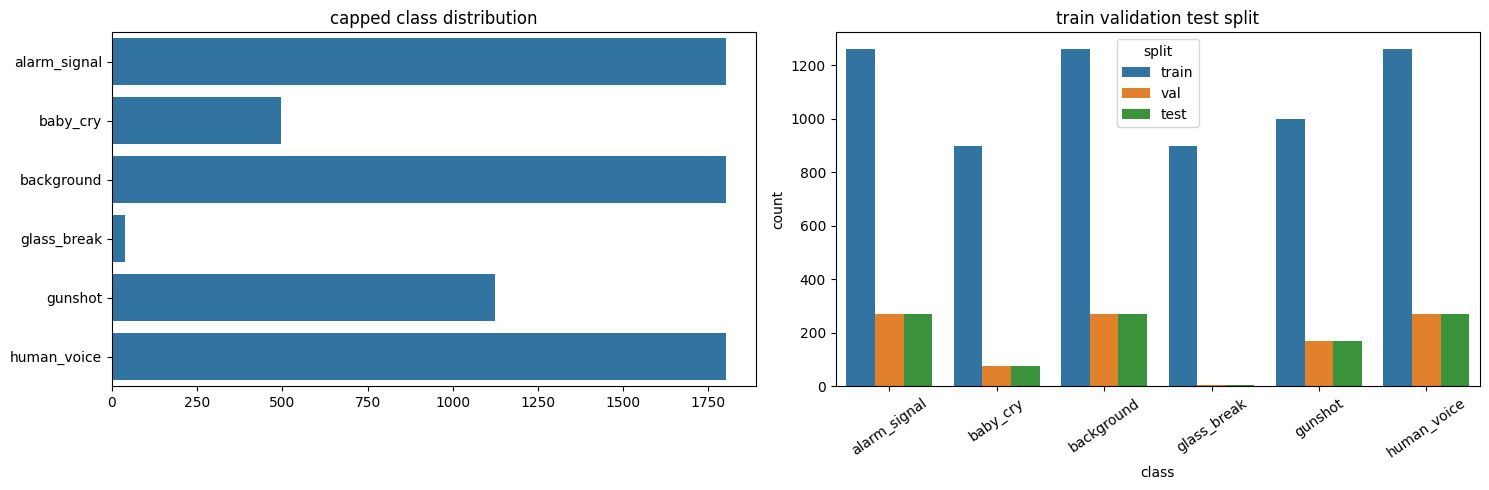

In [5]:
scanners = [("ESC-50", scan_esc50), ("UrbanSound8K", scan_urbansound8k), ("RAVDESS", scan_ravdess), ("CREMA-D", scan_cremad), ("Gunshot", scan_gunshot), ("Siren", scan_siren), ("BabyCry", scan_babycry), ("Music", scan_music)]
all_samples = []
source_counts = {}
for name, fn in scanners:
    rows = fn()
    source_counts[name] = len(rows)
    all_samples.extend(rows)
    print(f"{name:14s}: {len(rows)}")
if not all_samples:
    raise RuntimeError("No audio datasets found")
raw_counts = dict(sorted(Counter(s[1] for s in all_samples).items()))
all_samples = deduplicate(all_samples)
dedup_counts = dict(sorted(Counter(s[1] for s in all_samples).items()))
all_samples = cap_per_class(all_samples, CFG["max_per_class"])
capped_counts = dict(sorted(Counter(s[1] for s in all_samples).items()))
train_s, val_s, test_s = prepare_splits(all_samples)
for cls, target in CFG["augment_targets"].items():
    train_s = augment_minority(train_s, cls, target)
split_counts = {"train": dict(sorted(Counter(s[1] for s in train_s).items())), "val": dict(sorted(Counter(s[1] for s in val_s).items())), "test": dict(sorted(Counter(s[1] for s in test_s).items()))}
DATA_AUDIT = {"classes": TARGET_CLASSES, "source_counts": source_counts, "raw_counts": raw_counts, "dedup_counts": dedup_counts, "capped_counts": capped_counts, "split_counts": split_counts, "split_rule": "70/15/15 stratified, deduplicate before split, augment train only"}
Path(CFG["output_dir"]).mkdir(parents=True, exist_ok=True)
with open(Path(CFG["output_dir"]) / "dataset_audit.json", "w", encoding="utf-8") as f:
    json.dump(DATA_AUDIT, f, indent=2)
display(Markdown("### Dataset audit"))
display(pd.DataFrame([{"stage": "raw", **raw_counts}, {"stage": "deduplicated", **dedup_counts}, {"stage": "capped", **capped_counts}]).fillna(0))
display(Markdown("### Split distribution"))
display(pd.DataFrame(split_counts).fillna(0).astype(int))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=list(capped_counts.values()), y=list(capped_counts.keys()), ax=axes[0])
axes[0].set_title("capped class distribution")
rows = []
for split, counts in split_counts.items():
    for cls, count in counts.items():
        rows.append({"split": split, "class": cls, "count": count})
sns.barplot(data=pd.DataFrame(rows), x="class", y="count", hue="split", ax=axes[1])
axes[1].tick_params(axis="x", rotation=35)
axes[1].set_title("train validation test split")
fig.tight_layout()
fig.savefig(Path(CFG["output_dir"]) / "dataset_split.png", dpi=160)
plt.show()

## Spectrogram Dataset and Loaders

In [6]:
def load_fixed_audio(path, random_crop=False):
    target = int(CFG["sample_rate"] * CFG["segment_duration"])
    y, _ = librosa.load(path, sr=CFG["sample_rate"], mono=True)
    if len(y) > target:
        if random_crop:
            start = np.random.randint(0, len(y) - target + 1)
        else:
            start = max(0, (len(y) - target) // 2)
        y = y[start:start + target]
    if len(y) < target:
        y = np.pad(y, (0, target - len(y)))
    return y.astype(np.float32)

def audio_to_spec(y):
    mel = librosa.feature.melspectrogram(y=y, sr=CFG["sample_rate"], n_mels=CFG["n_mels"], fmax=CFG["sample_rate"] // 2)
    db = librosa.power_to_db(mel, ref=np.max, top_db=80)
    spec = np.clip((db + 80) / 80, 0, 1).astype(np.float32)
    spec = torch.tensor(spec).unsqueeze(0)
    spec = F.interpolate(spec.unsqueeze(0), size=(CFG["image_size"], CFG["image_size"]), mode="bilinear", align_corners=False).squeeze(0)
    return spec

def augment_waveform(y):
    if np.random.random() < 0.45:
        shift = np.random.randint(-int(0.18 * CFG["sample_rate"]), int(0.18 * CFG["sample_rate"]) + 1)
        y = np.roll(y, shift)
    if np.random.random() < 0.45:
        y = (y * np.random.uniform(0.70, 1.30)).astype(np.float32)
    if np.random.random() < 0.35:
        y = (y + np.random.normal(0, 0.004, len(y))).astype(np.float32)
    if np.random.random() < 0.20:
        width = np.random.randint(int(0.04 * len(y)), int(0.12 * len(y)))
        start = np.random.randint(0, max(1, len(y) - width))
        y[start:start + width] = 0
    return y.astype(np.float32)

def mask_spectrogram(spec):
    if np.random.random() < 0.35:
        width = np.random.randint(4, 18)
        start = np.random.randint(0, max(1, spec.shape[1] - width))
        spec[:, start:start + width, :] = 0
    if np.random.random() < 0.35:
        width = np.random.randint(6, 28)
        start = np.random.randint(0, max(1, spec.shape[2] - width))
        spec[:, :, start:start + width] = 0
    return spec

class AudioFinalDataset(Dataset):
    def __init__(self, samples, augment=False):
        self.samples = samples
        self.augment = augment
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label, source = self.samples[idx]
        try:
            y = load_fixed_audio(path, random_crop=self.augment)
        except Exception:
            y = np.zeros(int(CFG["sample_rate"] * CFG["segment_duration"]), dtype=np.float32)
        if self.augment:
            y = augment_waveform(y)
        spec = audio_to_spec(y)
        if self.augment:
            spec = mask_spectrogram(spec)
        wave = torch.tensor(y, dtype=torch.float32)
        return spec, wave, CLASS2IDX[label], path, source

def collate_batch(batch):
    specs = torch.stack([x[0] for x in batch])
    waves = torch.stack([x[1] for x in batch])
    labels = torch.tensor([x[2] for x in batch], dtype=torch.long)
    paths = [x[3] for x in batch]
    sources = [x[4] for x in batch]
    return specs, waves, labels, paths, sources

train_dl = DataLoader(AudioFinalDataset(train_s, augment=True), batch_size=CFG["batch_size"], shuffle=True, num_workers=CFG["num_workers"], pin_memory=True, drop_last=True, collate_fn=collate_batch)
val_dl = DataLoader(AudioFinalDataset(val_s), batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"], pin_memory=True, collate_fn=collate_batch)
test_dl = DataLoader(AudioFinalDataset(test_s), batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"], pin_memory=True, collate_fn=collate_batch)
CLASS_WEIGHTS = class_weights(train_s).to(DEVICE)
print(f"train={len(train_s)} val={len(val_s)} test={len(test_s)}")
print({cls: round(float(CLASS_WEIGHTS[idx]), 3) for cls, idx in CLASS2IDX.items()})

train=6580 val=1059 test=1059
{'gunshot': 1.038, 'glass_break': 1.094, 'alarm_signal': 0.925, 'human_voice': 0.925, 'baby_cry': 1.094, 'background': 0.925}


## ResNet34 Spectrogram Model

In [7]:
class ResNet34Spectrogram(nn.Module):
    def __init__(self):
        super().__init__()
        try:
            with mute_output(CFG["quiet_external_output"]):
                self.backbone = models.resnet34(weights=models.ResNet34_Weights.DEFAULT, progress=False)
        except Exception:
            self.backbone = models.resnet34(weights=None, progress=False)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.head = nn.Sequential(nn.Dropout(0.38), nn.Linear(in_features, 384), nn.ReLU(), nn.BatchNorm1d(384), nn.Dropout(0.28), nn.Linear(384, NUM_CLASSES))
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))
        self.cam_layer = self.backbone.layer4[-1].conv2
    def forward(self, spec, wave=None):
        x = spec.repeat(1, 3, 1, 1)
        x = (x - self.mean) / self.std
        return self.head(self.backbone(x))
    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

RUN_NAME = "resnet34_final"
model = ResNet34Spectrogram().to(DEVICE)
display(Markdown("### Model summary"))
display(pd.DataFrame([{"model": RUN_NAME, "classes": NUM_CLASSES, "parameters": int(sum(p.numel() for p in model.parameters()))}]))

### Model summary

,model,classes,parameters
0,resnet34_final,6,21484742


## Training and Evaluation Utilities

In [8]:
def count_params(model):
    return int(sum(p.numel() for p in model.parameters()))

def model_size_mb(path):
    return round(Path(path).stat().st_size / (1024 * 1024), 3) if Path(path).exists() else 0.0

def mixup(spec, wave, labels, alpha):
    if alpha <= 0:
        return spec, wave, labels, labels, 1.0
    lam = max(np.random.beta(alpha, alpha), 0.5)
    idx = torch.randperm(spec.size(0), device=spec.device)
    return lam * spec + (1 - lam) * spec[idx], lam * wave + (1 - lam) * wave[idx], labels, labels[idx], lam

def train_loss(criterion, logits, ya, yb, lam):
    return lam * criterion(logits, ya) + (1 - lam) * criterion(logits, yb)

def shift_specs(specs, shift):
    if shift == 0:
        return specs
    out = torch.zeros_like(specs)
    if shift > 0:
        out[..., shift:] = specs[..., :-shift]
    else:
        out[..., :shift] = specs[..., -shift:]
    return out

@torch.no_grad()
def collect_outputs(model, loader, temperature=1.0, tta_shifts=None):
    model.eval()
    shifts = tta_shifts if tta_shifts is not None else [0]
    probs, preds, labels, paths, sources = [], [], [], [], []
    for specs, waves, y, p, s in loader:
        specs = specs.to(DEVICE)
        waves = waves.to(DEVICE)
        prob = 0
        for shift in shifts:
            logits = model(shift_specs(specs, int(shift)), waves) / max(float(temperature), 1e-6)
            prob = prob + F.softmax(logits, dim=1)
        pr = (prob / len(shifts)).cpu().numpy()
        probs.append(pr)
        preds.extend(pr.argmax(axis=1).tolist())
        labels.extend(y.numpy().tolist())
        paths.extend(p)
        sources.extend(s)
    probs = np.concatenate(probs, axis=0)
    return {"probs": probs, "preds": np.array(preds), "labels": np.array(labels), "paths": paths, "sources": sources}

@torch.no_grad()
def macro_f1_on_loader(model, loader):
    out = collect_outputs(model, loader)
    return f1_score(out["labels"], out["preds"], average="macro", zero_division=0)

def tune_temperature(model, loader):
    model.eval()
    logits_list, labels_list = [], []
    with torch.no_grad():
        for specs, waves, y, _, _ in loader:
            logits_list.append(model(specs.to(DEVICE), waves.to(DEVICE)))
            labels_list.append(y.to(DEVICE))
    logits = torch.cat(logits_list)
    labels = torch.cat(labels_list)
    best_t, best_loss = 1.0, float("inf")
    for t in np.linspace(0.5, 2.5, 41):
        loss = F.cross_entropy(logits / float(t), labels).item()
        if loss < best_loss:
            best_t, best_loss = float(t), float(loss)
    return best_t

def ece_score(labels, probs, bins=10):
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == labels).astype(float)
    ece = 0.0
    edges = np.linspace(0, 1, bins + 1)
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf >= lo) & (conf < hi if hi < 1 else conf <= hi)
        if mask.any():
            ece += float(mask.mean()) * abs(float(correct[mask].mean()) - float(conf[mask].mean()))
    return round(ece, 5)

def metric_dict(name, model, output, temperature, history, path, latency_ms):
    labels, preds, probs = output["labels"], output["preds"], output["probs"]
    try:
        auc = roc_auc_score(labels, probs, labels=list(range(NUM_CLASSES)), multi_class="ovr", average="macro")
    except Exception:
        auc = float("nan")
    return {
        "model": name,
        "accuracy": round(float(accuracy_score(labels, preds)), 5),
        "macro_f1": round(float(f1_score(labels, preds, average="macro", zero_division=0)), 5),
        "weighted_f1": round(float(f1_score(labels, preds, average="weighted", zero_division=0)), 5),
        "precision_macro": round(float(precision_score(labels, preds, average="macro", zero_division=0)), 5),
        "recall_macro": round(float(recall_score(labels, preds, average="macro", zero_division=0)), 5),
        "auc_macro_ovr": None if np.isnan(auc) else round(float(auc), 5),
        "ece": ece_score(labels, probs),
        "temperature": round(float(temperature), 4),
        "parameters": count_params(model),
        "model_mb": model_size_mb(path),
        "latency_ms": round(float(latency_ms), 3),
        "best_val_f1": round(float(max([h["val_f1"] for h in history] or [0])), 5),
        "tta_shifts": CFG["tta_shifts"]
    }

def measure_latency(model, loader, repeats=20, tta_shifts=None):
    model.eval()
    shifts = tta_shifts if tta_shifts is not None else [0]
    specs, waves, _, _, _ = next(iter(loader))
    specs = specs.to(DEVICE)
    waves = waves.to(DEVICE)
    with torch.no_grad():
        for _ in range(4):
            for shift in shifts:
                model(shift_specs(specs, int(shift)), waves)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.time()
        for _ in range(repeats):
            for shift in shifts:
                model(shift_specs(specs, int(shift)), waves)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
    return 1000 * (time.time() - start) / max(1, repeats * specs.size(0))

## Final ResNet Training

In [9]:
def optimizer_for_phase(model, phase):
    if phase == "frozen":
        return torch.optim.AdamW([{"params": model.head.parameters(), "lr": CFG["head_lr"]}], weight_decay=CFG["weight_decay"])
    return torch.optim.AdamW([
        {"params": model.backbone.parameters(), "lr": CFG["backbone_lr"]},
        {"params": model.head.parameters(), "lr": CFG["full_head_lr"]}
    ], weight_decay=CFG["weight_decay"])

def train_resnet_final(model):
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS, label_smoothing=CFG["label_smoothing"])
    history = []
    best_state = None
    best_val = -1.0
    phases = [("frozen", CFG["frozen_epochs"]), ("full", CFG["full_epochs"])]
    for phase, epochs in phases:
        if phase == "frozen":
            model.freeze_backbone()
        else:
            model.unfreeze_backbone()
        optimizer = optimizer_for_phase(model, phase)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs * len(train_dl)))
        patience = 0
        for ep in range(epochs):
            model.train()
            total_loss, total_correct, total = 0.0, 0, 0
            for specs, waves, labels, _, _ in tqdm(train_dl, desc=f"{phase} {ep + 1}/{epochs}", leave=False, disable=not CFG["show_progress"]):
                specs = specs.to(DEVICE)
                waves = waves.to(DEVICE)
                labels = labels.to(DEVICE)
                mx, mw, ya, yb, lam = mixup(specs, waves, labels, CFG["mixup_alpha"])
                logits = model(mx, mw)
                loss = train_loss(criterion, logits, ya, yb, lam)
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                total_loss += loss.item() * specs.size(0)
                total_correct += (logits.argmax(1) == labels).sum().item()
                total += specs.size(0)
            val_f1 = macro_f1_on_loader(model, val_dl)
            lr_values = [group["lr"] for group in optimizer.param_groups]
            row = {"phase": phase, "epoch": ep + 1, "loss": total_loss / max(1, total), "train_acc": total_correct / max(1, total), "val_f1": val_f1, "lr_min": min(lr_values), "lr_max": max(lr_values)}
            history.append(row)
            print(f"{RUN_NAME} | {phase} {ep + 1}/{epochs} | loss={row['loss']:.4f} | acc={row['train_acc']:.4f} | val_f1={row['val_f1']:.4f} | lr={row['lr_min']:.2e}-{row['lr_max']:.2e}")
            if val_f1 > best_val:
                best_val = val_f1
                patience = 0
                best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            else:
                patience += 1
            if patience >= CFG["early_stop_patience"]:
                print(f"Early stop at {phase} epoch {ep + 1}")
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    temperature = tune_temperature(model, val_dl)
    path = Path(CFG["model_dir"]) / f"{RUN_NAME}.pt"
    torch.save({"model_state": model.state_dict(), "classes": TARGET_CLASSES, "cfg": CFG, "history": history, "temperature": temperature, "model_name": RUN_NAME}, path)
    test_output = collect_outputs(model, test_dl, temperature=temperature, tta_shifts=CFG["tta_shifts"])
    latency = measure_latency(model, test_dl, tta_shifts=CFG["tta_shifts"])
    metrics = metric_dict(RUN_NAME, model, test_output, temperature, history, path, latency)
    pd.DataFrame(history).to_csv(Path(CFG["output_dir"]) / f"{RUN_NAME}_history.csv", index=False)
    with open(Path(CFG["output_dir"]) / f"{RUN_NAME}_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)
    return {"model": model, "history": history, "output": test_output, "metrics": metrics, "path": str(path), "temperature": temperature}

RUN = train_resnet_final(model)
metrics_df = pd.DataFrame([RUN["metrics"]])
metrics_df.to_csv(Path(CFG["output_dir"]) / "final_metrics.csv", index=False)
with open(Path(CFG["output_dir"]) / "final_metrics.json", "w", encoding="utf-8") as f:
    json.dump(RUN["metrics"], f, indent=2)
display(Markdown("### Final ResNet metrics"))
display(metrics_df.style.format({"accuracy": "{:.4f}", "macro_f1": "{:.4f}", "weighted_f1": "{:.4f}", "precision_macro": "{:.4f}", "recall_macro": "{:.4f}", "auc_macro_ovr": "{:.4f}", "ece": "{:.4f}", "latency_ms": "{:.2f}", "model_mb": "{:.2f}", "temperature": "{:.3f}", "best_val_f1": "{:.4f}"}))

resnet34_final | frozen 1/4 | loss=1.4230 | acc=0.4924 | val_f1=0.7318 | lr=6.83e-04-6.83e-04
resnet34_final | frozen 2/4 | loss=1.3292 | acc=0.5305 | val_f1=0.6731 | lr=4.00e-04-4.00e-04
resnet34_final | frozen 3/4 | loss=1.3175 | acc=0.5425 | val_f1=0.7128 | lr=1.17e-04-1.17e-04
resnet34_final | frozen 4/4 | loss=1.3137 | acc=0.5416 | val_f1=0.7082 | lr=0.00e+00-0.00e+00
resnet34_final | full 1/16 | loss=1.0471 | acc=0.6672 | val_f1=0.8127 | lr=6.93e-05-3.96e-04
resnet34_final | full 2/16 | loss=0.8936 | acc=0.7239 | val_f1=0.8837 | lr=6.73e-05-3.85e-04
resnet34_final | full 3/16 | loss=0.8114 | acc=0.7602 | val_f1=0.8991 | lr=6.41e-05-3.66e-04
resnet34_final | full 4/16 | loss=0.8432 | acc=0.7288 | val_f1=0.8983 | lr=5.97e-05-3.41e-04
resnet34_final | full 5/16 | loss=0.8421 | acc=0.7274 | val_f1=0.8918 | lr=5.44e-05-3.11e-04
resnet34_final | full 6/16 | loss=0.8199 | acc=0.7343 | val_f1=0.8981 | lr=4.84e-05-2.77e-04
resnet34_final | full 7/16 | loss=0.7514 | acc=0.7628 | val_f1=0.9

### Final ResNet metrics

,model,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,auc_macro_ovr,ece,temperature,parameters,model_mb,latency_ms,best_val_f1,tta_shifts
0,resnet34_final,0.9698,0.9248,0.9705,0.8974,0.9802,0.9972,0.0160,0.700,21484742,82.11,4.20,0.9134,"[-8, 0, 8]"


## Evaluation, Charts, and Calibration

### Classification report

,class,precision,recall,f1-score,support
0,gunshot,0.9769,1.0000,0.9883,169
1,glass_break,0.5000,1.0000,0.6667,6
2,alarm_signal,0.9815,0.9852,0.9834,270
3,human_voice,0.9740,0.9704,0.9722,270
4,baby_cry,0.9867,1.0000,0.9933,74
5,background,0.9653,0.9259,0.9452,270
6,accuracy,0.9698,0.9698,0.9698,1
7,macro avg,0.8974,0.9802,0.9248,1059
8,weighted avg,0.9723,0.9698,0.9705,1059


### Top confusions

,true,predicted,count
3,human_voice,background,6
7,background,human_voice,6
6,background,alarm_signal,5
5,background,glass_break,4
4,background,gunshot,4
1,alarm_signal,background,3
2,human_voice,glass_break,2
0,alarm_signal,human_voice,1
8,background,baby_cry,1


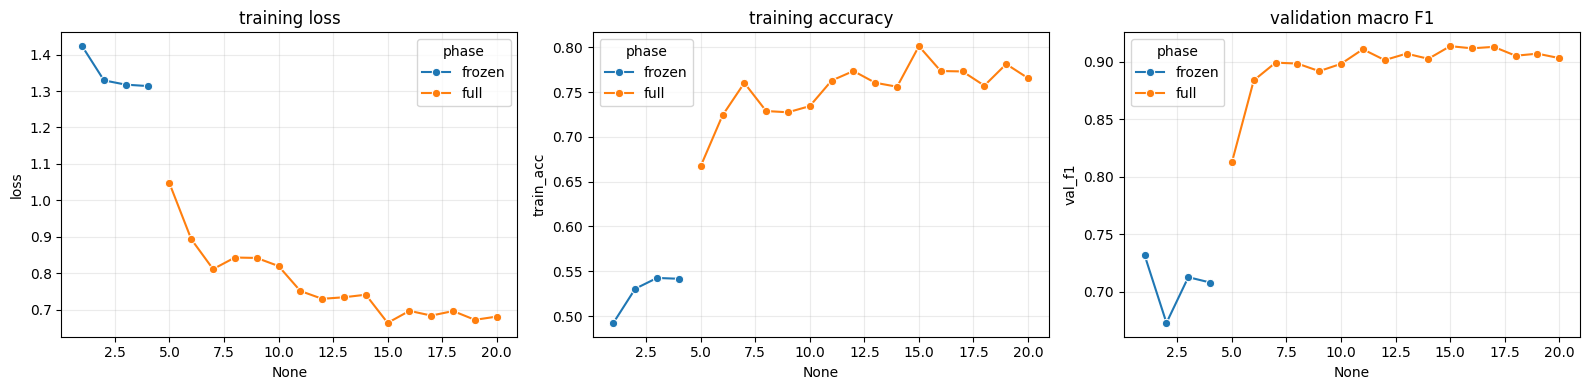

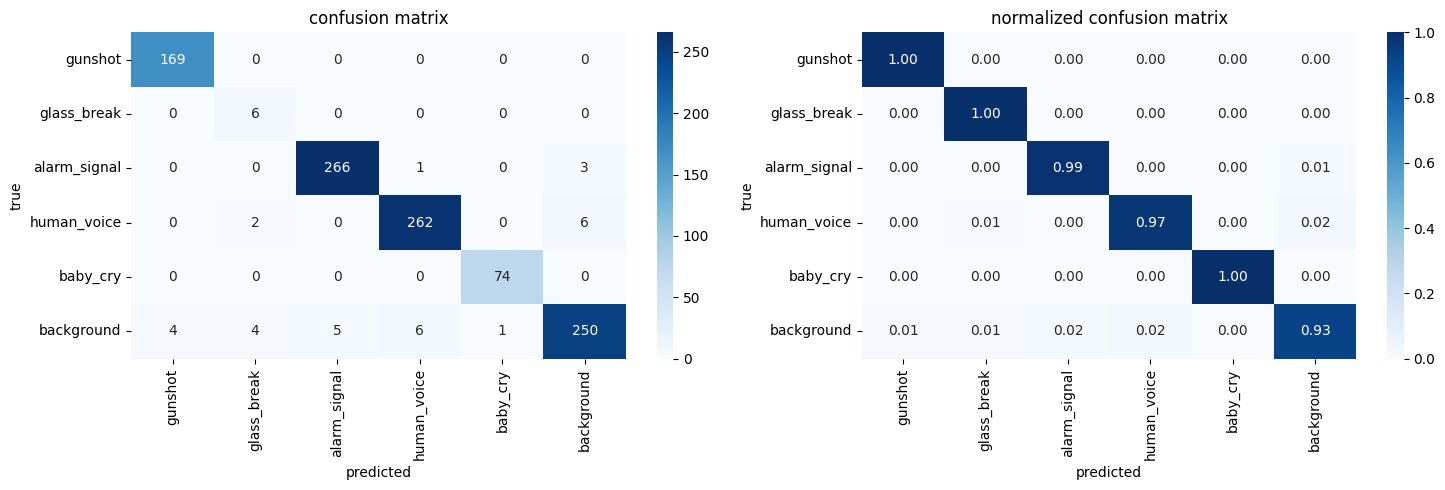

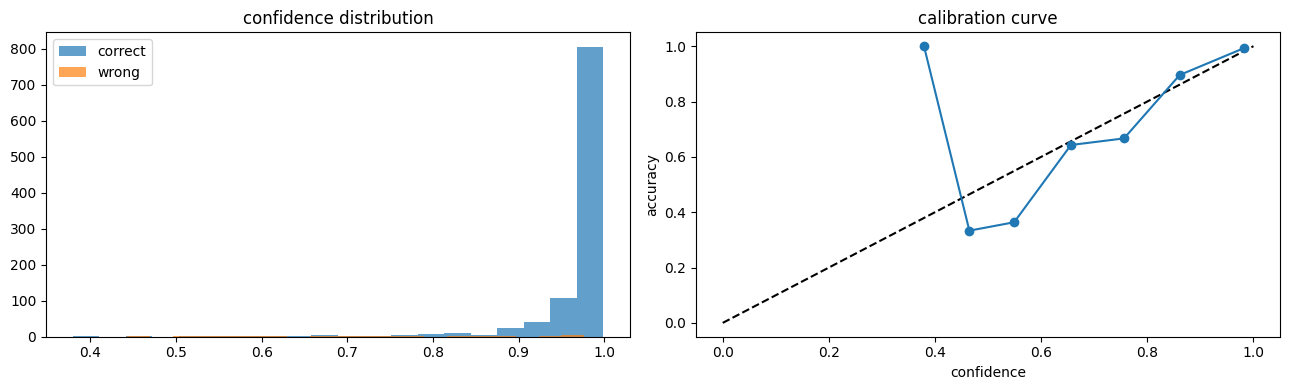

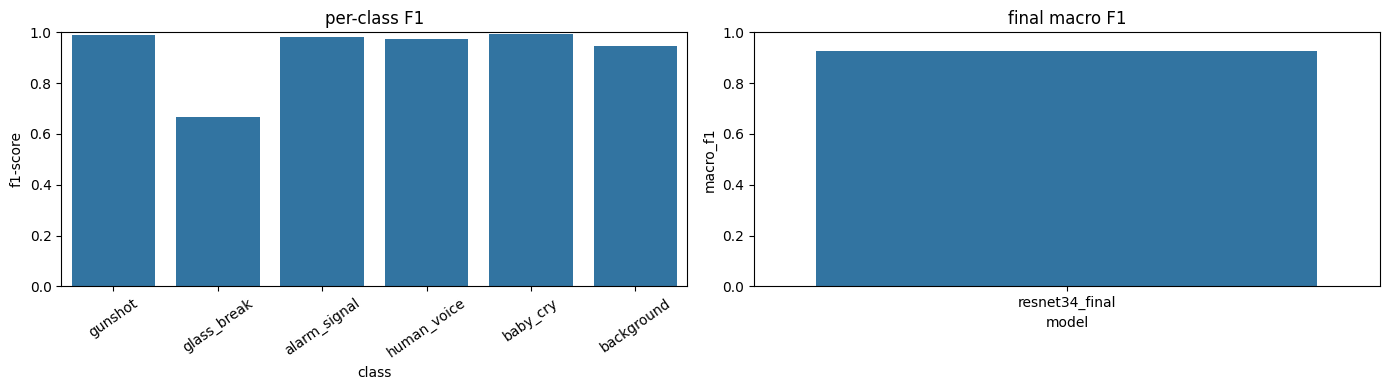

In [10]:
def plot_history(history):
    df = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    sns.lineplot(data=df, x=df.index + 1, y="loss", hue="phase", marker="o", ax=axes[0])
    sns.lineplot(data=df, x=df.index + 1, y="train_acc", hue="phase", marker="o", ax=axes[1])
    sns.lineplot(data=df, x=df.index + 1, y="val_f1", hue="phase", marker="o", ax=axes[2])
    axes[0].set_title("training loss")
    axes[1].set_title("training accuracy")
    axes[2].set_title("validation macro F1")
    for ax in axes:
        ax.grid(True, alpha=0.25)
    fig.tight_layout()
    fig.savefig(Path(CFG["output_dir"]) / "learning_curve.png", dpi=160)
    plt.show()

def report_frame(output):
    report = classification_report(output["labels"], output["preds"], target_names=TARGET_CLASSES, zero_division=0, output_dict=True)
    df = pd.DataFrame(report).T.reset_index().rename(columns={"index": "class"})
    for col in ["precision", "recall", "f1-score", "support"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def top_confusions_frame(output, limit=12):
    cm = confusion_matrix(output["labels"], output["preds"], labels=list(range(NUM_CLASSES)))
    rows = []
    for i, true_name in enumerate(TARGET_CLASSES):
        for j, pred_name in enumerate(TARGET_CLASSES):
            if i != j and cm[i, j] > 0:
                rows.append({"true": true_name, "predicted": pred_name, "count": int(cm[i, j])})
    return pd.DataFrame(rows).sort_values("count", ascending=False).head(limit) if rows else pd.DataFrame(columns=["true", "predicted", "count"])

def plot_confusion(output):
    cm = confusion_matrix(output["labels"], output["preds"], labels=list(range(NUM_CLASSES)))
    cmn = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[0])
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[1])
    axes[0].set_title("confusion matrix")
    axes[1].set_title("normalized confusion matrix")
    for ax in axes:
        ax.set_xlabel("predicted")
        ax.set_ylabel("true")
    fig.tight_layout()
    fig.savefig(Path(CFG["output_dir"]) / "confusion_matrix.png", dpi=160)
    plt.show()

def plot_calibration(output):
    probs = output["probs"]
    labels = output["labels"]
    preds = probs.argmax(axis=1)
    conf = probs.max(axis=1)
    correct = (preds == labels).astype(float)
    bins = np.linspace(0, 1, 11)
    xs, ys = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf >= lo) & (conf < hi if hi < 1 else conf <= hi)
        if mask.any():
            xs.append(conf[mask].mean())
            ys.append(correct[mask].mean())
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(conf[preds == labels], bins=20, alpha=0.7, label="correct")
    axes[0].hist(conf[preds != labels], bins=20, alpha=0.7, label="wrong")
    axes[0].legend()
    axes[0].set_title("confidence distribution")
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="black")
    axes[1].plot(xs, ys, marker="o")
    axes[1].set_title("calibration curve")
    axes[1].set_xlabel("confidence")
    axes[1].set_ylabel("accuracy")
    fig.tight_layout()
    fig.savefig(Path(CFG["output_dir"]) / "calibration.png", dpi=160)
    plt.show()

display(Markdown("### Classification report"))
report_df = report_frame(RUN["output"])
report_df.to_csv(Path(CFG["output_dir"]) / "classification_report.csv", index=False)
display(report_df.style.format({"precision": "{:.4f}", "recall": "{:.4f}", "f1-score": "{:.4f}", "support": "{:.0f}"}))
display(Markdown("### Top confusions"))
confusions_df = top_confusions_frame(RUN["output"])
confusions_df.to_csv(Path(CFG["output_dir"]) / "top_confusions.csv", index=False)
display(confusions_df)
plot_history(RUN["history"])
plot_confusion(RUN["output"])
plot_calibration(RUN["output"])
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
class_rows = report_df[report_df["class"].isin(TARGET_CLASSES)].copy()
sns.barplot(data=class_rows, x="class", y="f1-score", ax=axes[0])
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_ylim(0, 1)
axes[0].set_title("per-class F1")
sns.barplot(data=metrics_df, x="model", y="macro_f1", ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title("final macro F1")
fig.tight_layout()
fig.savefig(Path(CFG["output_dir"]) / "final_score_summary.png", dpi=160)
plt.show()

## Explainability

### XAI example: alarm_signal

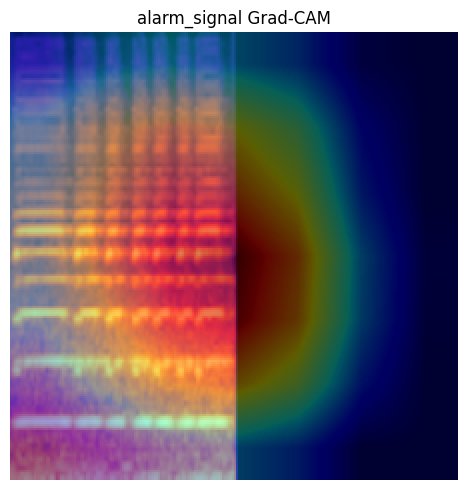

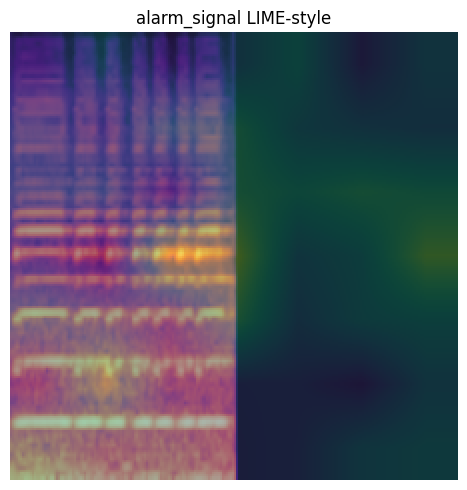

### XAI example: gunshot

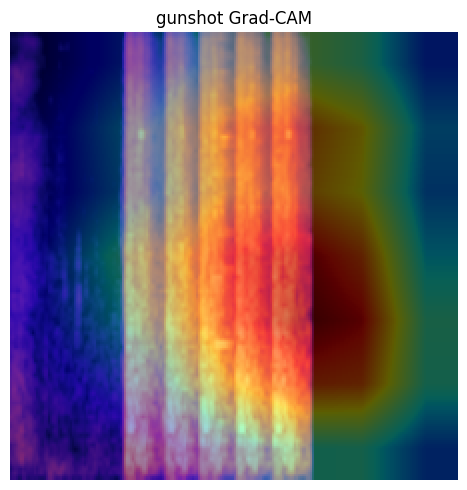

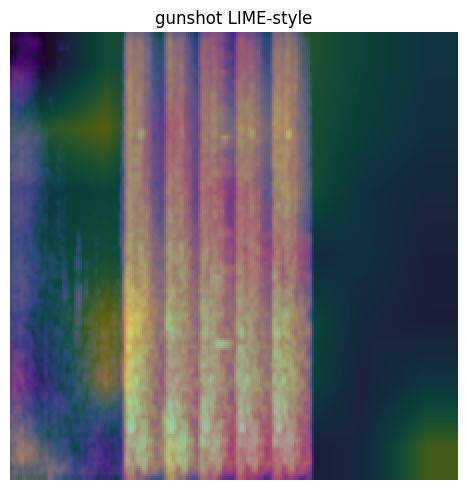

### XAI example: background

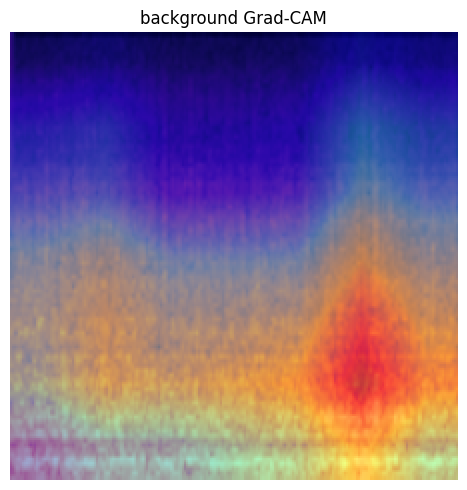

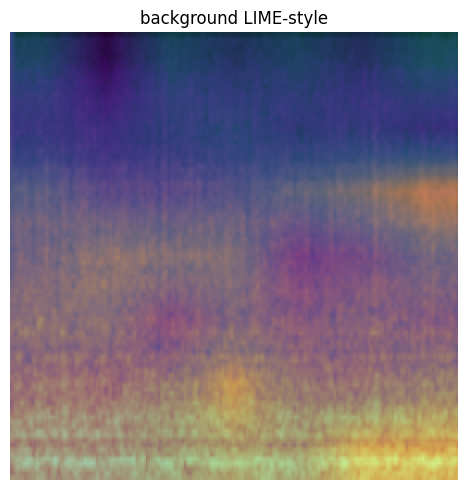

### XAI example: baby_cry

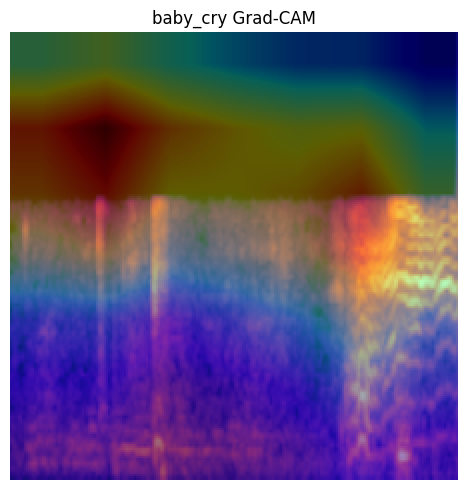

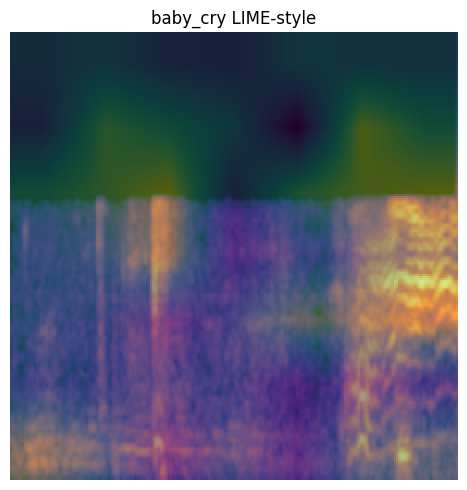

### XAI example: human_voice

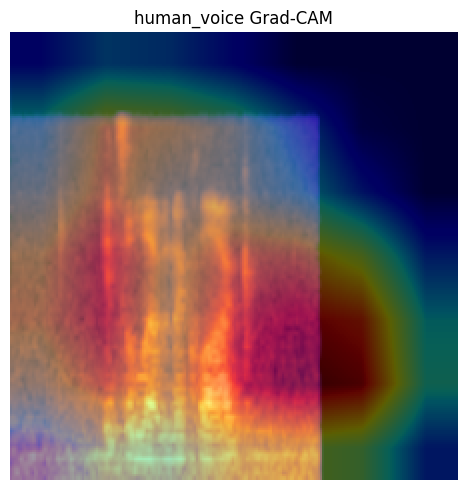

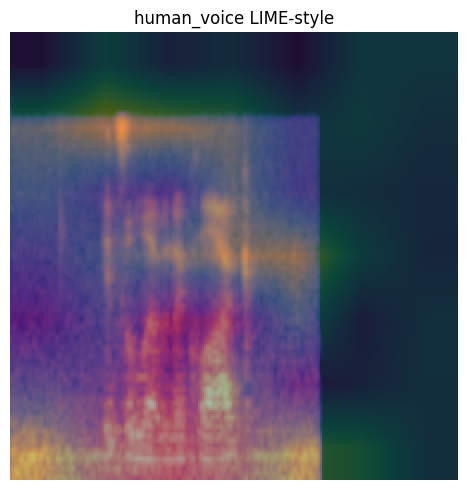

### XAI example: glass_break

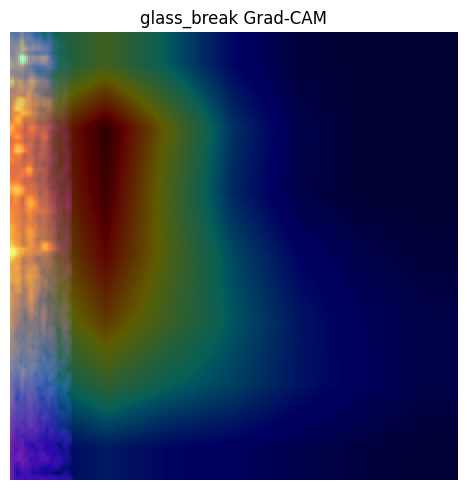

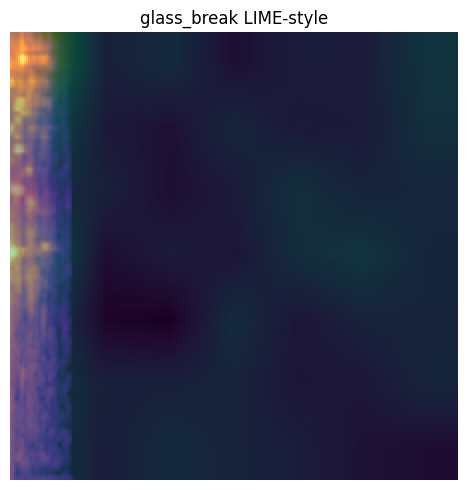

### XAI artifact manifest

,class,artifact,path
0,alarm_signal,alarm_signal_grad-cam_gradcam.png,/kaggle/working/audio_resnet_final_vf/xai/alar...
1,alarm_signal,alarm_signal_lime-style_lime_style.png,/kaggle/working/audio_resnet_final_vf/xai/alar...
2,gunshot,gunshot_grad-cam_gradcam.png,/kaggle/working/audio_resnet_final_vf/xai/guns...
3,gunshot,gunshot_lime-style_lime_style.png,/kaggle/working/audio_resnet_final_vf/xai/guns...
4,background,background_grad-cam_gradcam.png,/kaggle/working/audio_resnet_final_vf/xai/back...
5,background,background_lime-style_lime_style.png,/kaggle/working/audio_resnet_final_vf/xai/back...
6,baby_cry,baby_cry_grad-cam_gradcam.png,/kaggle/working/audio_resnet_final_vf/xai/baby...
7,baby_cry,baby_cry_lime-style_lime_style.png,/kaggle/working/audio_resnet_final_vf/xai/baby...
8,human_voice,human_voice_grad-cam_gradcam.png,/kaggle/working/audio_resnet_final_vf/xai/huma...
9,human_voice,human_voice_lime-style_lime_style.png,/kaggle/working/audio_resnet_final_vf/xai/huma...


In [11]:
def examples_per_class(run):
    out = run["output"]
    selected = []
    seen = Counter()
    for idx, (label, pred) in enumerate(zip(out["labels"], out["preds"])):
        cls = int(label)
        if pred == label and seen[cls] < CFG["xai_examples_per_class"]:
            selected.append((out["paths"][idx], IDX2CLASS[cls], out["sources"][idx]))
            seen[cls] += 1
    for cls in range(NUM_CLASSES):
        if seen[cls] >= CFG["xai_examples_per_class"]:
            continue
        idxs = np.where(out["labels"] == cls)[0]
        if len(idxs):
            best_idx = int(idxs[np.argmax(out["probs"][idxs, cls])])
            selected.append((out["paths"][best_idx], IDX2CLASS[cls], out["sources"][best_idx]))
            seen[cls] += 1
    return selected

def gradcam_spectrogram(model, spec, label, title):
    model.eval()
    acts, grads = [], []
    def fhook(module, inp, out):
        acts.append(out.detach())
    def bhook(module, gin, gout):
        grads.append(gout[0].detach())
    h1 = model.cam_layer.register_forward_hook(fhook)
    h2 = model.cam_layer.register_full_backward_hook(bhook)
    x = spec.unsqueeze(0).to(DEVICE)
    model.zero_grad()
    logits = model(x)
    score = logits[0, int(label)]
    score.backward()
    h1.remove()
    h2.remove()
    if not acts or not grads:
        return None
    weights = grads[0].mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * acts[0]).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=(CFG["image_size"], CFG["image_size"]), mode="bilinear", align_corners=False)[0, 0]
    cam = cam.cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(spec[0].numpy(), origin="lower", cmap="magma")
    ax.imshow(cam, origin="lower", cmap="jet", alpha=0.38)
    ax.set_title(title)
    ax.axis("off")
    safe = title.lower().replace(" ", "_").replace("/", "_")
    path = Path(CFG["xai_dir"]) / f"{safe}_gradcam.png"
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.show()
    return str(path)

def spec_lime(model, spec, label, title, grid=7):
    model.eval()
    cells = grid * grid
    xs, ys = [], []
    with torch.no_grad():
        for _ in range(CFG["lime_masks"]):
            mask_vec = np.random.binomial(1, 0.65, cells).astype(np.float32)
            mask = torch.tensor(mask_vec.reshape(grid, grid)).unsqueeze(0).unsqueeze(0)
            mask = F.interpolate(mask, size=(CFG["image_size"], CFG["image_size"]), mode="nearest").squeeze(0)
            masked = spec * mask
            prob = F.softmax(model(masked.unsqueeze(0).to(DEVICE)), dim=1)[0, int(label)].item()
            xs.append(mask_vec)
            ys.append(prob)
    ridge = Ridge(alpha=1.0).fit(np.array(xs), np.array(ys))
    heat = ridge.coef_.reshape(grid, grid)
    heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
    heat = F.interpolate(torch.tensor(heat).unsqueeze(0).unsqueeze(0).float(), size=(CFG["image_size"], CFG["image_size"]), mode="bilinear", align_corners=False)[0, 0].numpy()
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(spec[0].numpy(), origin="lower", cmap="magma")
    ax.imshow(heat, origin="lower", cmap="viridis", alpha=0.42)
    ax.set_title(title)
    ax.axis("off")
    safe = title.lower().replace(" ", "_").replace("/", "_")
    path = Path(CFG["xai_dir"]) / f"{safe}_lime_style.png"
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.show()
    return str(path)

XAI_FILES = []
for path, label_name, source in examples_per_class(RUN):
    spec, wave, label, _, _ = AudioFinalDataset([(path, label_name, source)])[0]
    display(Markdown(f"### XAI example: {label_name}"))
    g = gradcam_spectrogram(RUN["model"], spec, label, f"{label_name} Grad-CAM")
    l = spec_lime(RUN["model"], spec, label, f"{label_name} LIME-style")
    for artifact in [g, l]:
        if artifact:
            XAI_FILES.append({"class": label_name, "artifact": Path(artifact).name, "path": artifact})
xai_df = pd.DataFrame(XAI_FILES)
with open(Path(CFG["xai_dir"]) / "xai_manifest.json", "w", encoding="utf-8") as f:
    json.dump(XAI_FILES, f, indent=2)
display(Markdown("### XAI artifact manifest"))
display(xai_df)

## Final Export Summary

In [12]:
summary = {
    "model": RUN_NAME,
    "metrics": RUN["metrics"],
    "dataset_audit": DATA_AUDIT,
    "xai_files": XAI_FILES,
    "outputs": {
        "output_dir": CFG["output_dir"],
        "model_dir": CFG["model_dir"],
        "xai_dir": CFG["xai_dir"],
        "model_path": RUN["path"],
        "metrics_csv": str(Path(CFG["output_dir"]) / "final_metrics.csv"),
        "metrics_json": str(Path(CFG["output_dir"]) / "final_metrics.json"),
        "summary_json": str(Path(CFG["output_dir"]) / "final_summary.json")
    }
}
with open(Path(CFG["output_dir"]) / "final_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
display(Markdown("### Final files"))
display(pd.DataFrame([summary["outputs"]]).T.rename(columns={0: "path"}))

### Final files

,path
output_dir,/kaggle/working/audio_resnet_final_vf
model_dir,/kaggle/working/audio_resnet_final_vf/models
xai_dir,/kaggle/working/audio_resnet_final_vf/xai
model_path,/kaggle/working/audio_resnet_final_vf/models/r...
metrics_csv,/kaggle/working/audio_resnet_final_vf/final_me...
metrics_json,/kaggle/working/audio_resnet_final_vf/final_me...
summary_json,/kaggle/working/audio_resnet_final_vf/final_su...


In [13]:
for path in [Path(CFG["output_dir"]) / "final_metrics.csv", Path(CFG["output_dir"]) / "final_metrics.json", Path(CFG["output_dir"]) / "final_summary.json", Path(CFG["output_dir"]) / "classification_report.csv", Path(CFG["output_dir"]) / "top_confusions.csv", Path(RUN["path"])]:
    if path.exists():
        display(FileLink(str(path)))

/kaggle/working/audio_resnet_final_vf/final_metrics.csv

/kaggle/working/audio_resnet_final_vf/final_metrics.json

/kaggle/working/audio_resnet_final_vf/final_summary.json

/kaggle/working/audio_resnet_final_vf/classification_report.csv

/kaggle/working/audio_resnet_final_vf/top_confusions.csv

/kaggle/working/audio_resnet_final_vf/models/resnet34_final.pt